In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso,Ridge,LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

In [23]:
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Logistic Regression

In [24]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:

models = {
    'logistic_regression': LogisticRegression(),
    'lasso': LogisticRegression(penalty='l1',solver='liblinear',C=1),
    'ridge': LogisticRegression(penalty='l2',C=1,max_iter=5000)
}
result=[]
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)*100
    result.append({'Model: ':name,'accuracy: ':acc,'coef':model.coef_})
    


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [32]:
result

[{'Model: ': 'logistic_regression',
  'accuracy: ': 96.49122807017544,
  'coef': array([[ 1.61902564,  0.53125809, -0.0241581 , -0.00496014, -0.06390645,
          -0.30115127, -0.41620355, -0.17874859, -0.09537256, -0.01936887,
           0.05484551,  0.74416269,  0.08312463, -0.1274985 , -0.00597313,
          -0.06071896, -0.08426243, -0.02292278, -0.02245144, -0.00532606,
           1.69732452, -0.59928468, -0.17092647, -0.02161007, -0.11325848,
          -0.90478656, -1.11886429, -0.32948468, -0.30661066, -0.08457808]])},
 {'Model: ': 'lasso',
  'accuracy: ': 95.6140350877193,
  'coef': array([[ 4.77398488,  0.14385753, -0.34422139, -0.01620751,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  1.74257975,  0.        , -0.09971156,  0.        ,
           0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
           0.        , -0.43436379, -0.01980802, -0.01530575,  0.        ,
           0.        , -3.33

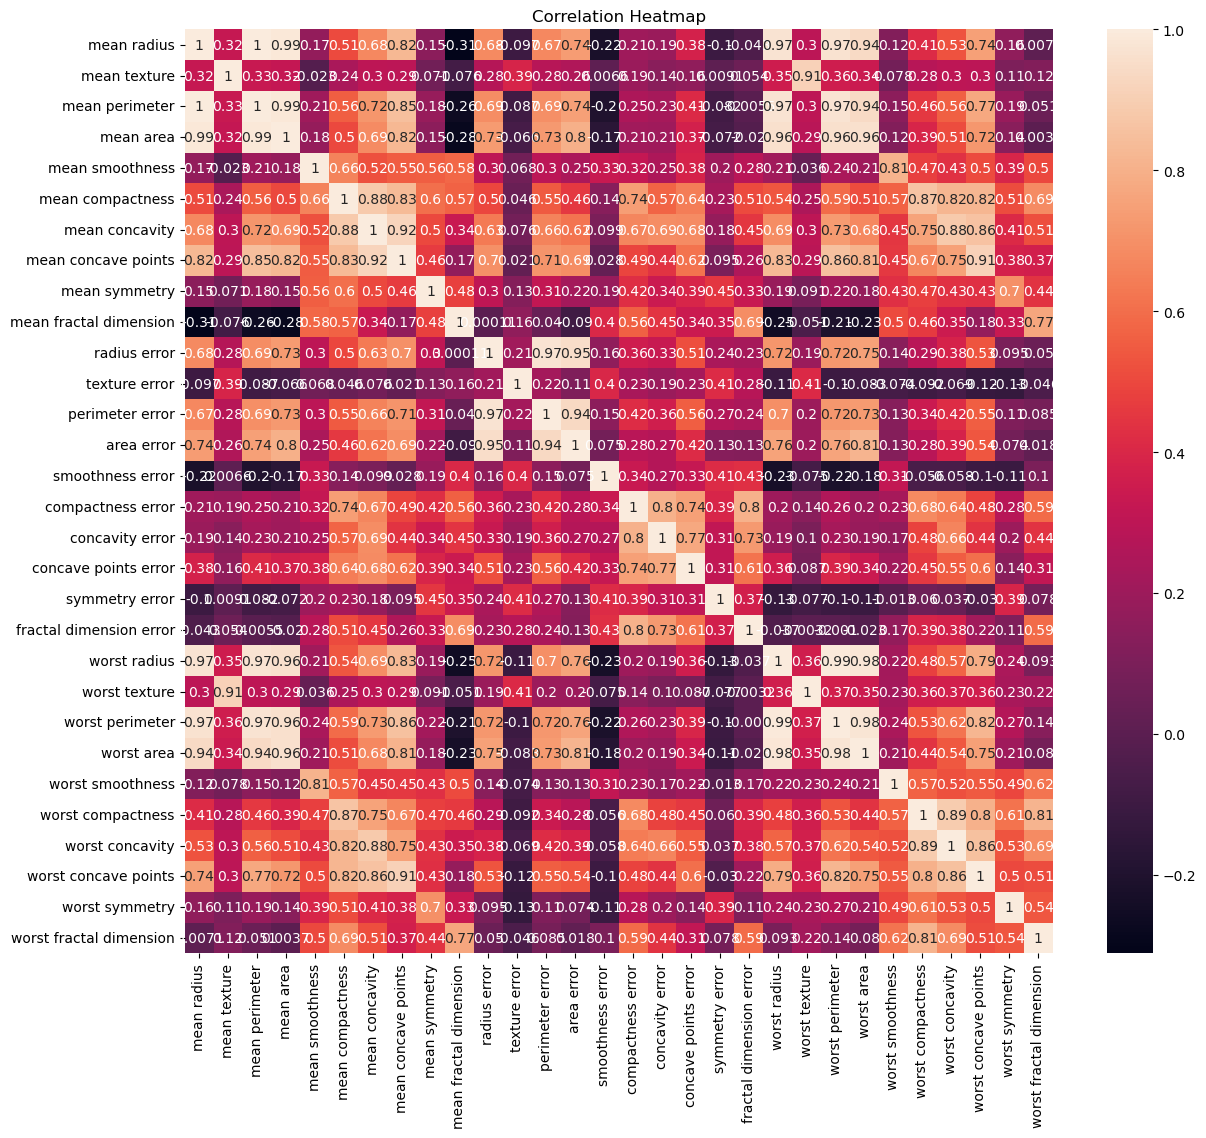

In [35]:
plt.figure(figsize=(14,12))
sns.heatmap(x.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

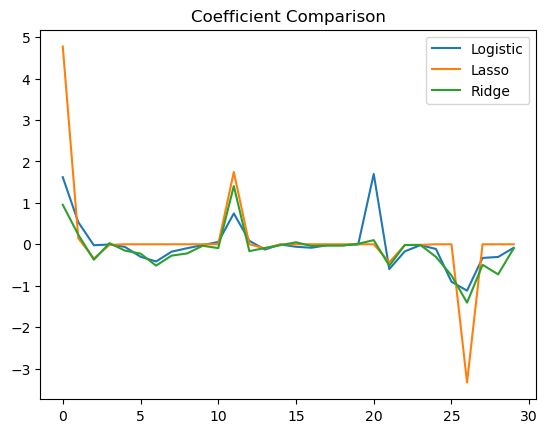

In [36]:
plt.plot(result[0]['coef'].flatten(), label='Logistic')
plt.plot(result[1]['coef'].flatten(), label='Lasso')
plt.plot(result[2]['coef'].flatten(), label='Ridge')

plt.legend()
plt.title("Coefficient Comparison")
plt.show()